In [7]:
"""
generate_pcm_dataset_2D_optimized.py

Optimized 2D PCM melting dataset generator using FiPy
(Heat conduction + phase change, no convection)

Safe for large dataset generation (50–250 cases)

Author: ChatGPT
"""

import os
import h5py
import numpy as np
from math import ceil
from datetime import datetime

from fipy import Grid2D, CellVariable, TransientTerm, DiffusionTerm, DefaultSolver

# ============================================================
# Paraffin PCM properties (typical)
# ============================================================
MATERIAL = {
    "rho": 780.0,      # kg/m^3
    "cp": 2000.0,      # J/(kg·K)
    "k": 0.2,          # W/(m·K)
    "L": 2.0e5,        # J/kg
    "Tm": 50.0,        # °C
    "dT": 2.0          # mushy half-width
}

# ============================================================
# Phase change functions
# ============================================================
def liquid_fraction(T, Tm, dT):
    Ts, Tl = Tm - dT, Tm + dT
    f = np.zeros_like(T)
    f[T >= Tl] = 1.0
    mask = (T > Ts) & (T < Tl)
    xi = (T[mask] - Ts) / (2 * dT)
    f[mask] = 3 * xi**2 - 2 * xi**3
    return f

def df_dT(T, Tm, dT):
    Ts, Tl = Tm - dT, Tm + dT
    df = np.zeros_like(T)
    mask = (T > Ts) & (T < Tl)
    xi = (T[mask] - Ts) / (2 * dT)
    df[mask] = (6 * xi - 6 * xi**2) / (2 * dT)
    return df

# ============================================================
# 2D PCM SOLVER (OPTIMIZED)
# ============================================================
def run_2d_case(params, outpath, save_every=50):
    if os.path.exists(outpath):
        print(f"✔ Skipping existing file: {outpath}")
        return

    # ----------------------------
    # Geometry and mesh
    # ----------------------------
    Lx, Ly = params["Lx"], params["Ly"]
    nx, ny = params["nx"], params["ny"]
    dx, dy = Lx / nx, Ly / ny

    mesh = Grid2D(nx=nx, ny=ny, dx=dx, dy=dy)

    # Cell center coordinates (for dataset)
    x = np.linspace(dx/2, Lx - dx/2, nx)
    y = np.linspace(dy/2, Ly - dy/2, ny)

    # ----------------------------
    # Variables
    T = CellVariable(mesh=mesh, value=params["T_init"])
    c_eff = CellVariable(mesh=mesh, value=params["cp"])
    q_src = CellVariable(mesh=mesh, value=0.0)
    
    # Correct FiPy equation
    eq = (
        TransientTerm(coeff=params["rho"] * c_eff)
        == DiffusionTerm(coeff=params["k"]) + q_src
    )

    

    # ----------------------------
    # Time loop
    # ----------------------------
    dt = params["dt"]
    nsteps = int(ceil(params["t_total"] / dt))

    times, T_hist, f_hist = [], [], []

    # Precompute x-coordinates of all cells (for heat flux mask)
    Xc, Yc = np.meshgrid(x, y)
    x_flat = Xc.ravel()

    for step in range(nsteps + 1):
        t = step * dt

        # Update apparent heat capacity
        c_eff.value = (
            params["cp"]
            + params["L"] * df_dT(T.value, params["Tm"], params["dT"])
        )

        # Heat flux (left boundary → volumetric approx)
        hf = params["heat_flux"](t) if callable(params["heat_flux"]) else params["heat_flux"]

        q = np.zeros(mesh.numberOfCells)
        left_cells = x_flat <= dx * 0.6
        q[left_cells] = hf / dx
        q_src.value = q

        # Solve
        eq.solve(var=T, dt=dt, solver=DefaultSolver())

        # Save snapshots
        if step % save_every == 0 or step == nsteps:
            times.append(t)
            T2D = T.value.reshape((ny, nx))
            T_hist.append(T2D)
            f_hist.append(liquid_fraction(T2D, params["Tm"], params["dT"]))

    # ----------------------------
    # Save to HDF5
    # ----------------------------
    with h5py.File(outpath, "w") as hf:
        g = hf.create_group("case")
        g.create_dataset("x", data=x)
        g.create_dataset("y", data=y)
        g.create_dataset("times", data=np.array(times))
        g.create_dataset("T", data=np.array(T_hist))
        g.create_dataset("f", data=np.array(f_hist))

        meta = g.create_group("params")
        for k, v in params.items():
            meta.attrs[k] = v if not callable(v) else "callable"
        meta.attrs["created"] = datetime.now().isoformat()

    print(f"✔ Saved {outpath}")

# ============================================================
# PARAMETER SWEEP (2D DATASET)
# ============================================================
def generate_dataset_2d(
    output_dir="pcm_dataset_2D",
    ncases=100
):
    os.makedirs(output_dir, exist_ok=True)

    heat_fluxes = np.linspace(500, 6000, 8)
    lengths = np.linspace(0.01, 0.04, 6)
    T_inits = [20.0, 30.0, 40.0]

    case_id = 0

    for q in heat_fluxes:
        for L in lengths:
            for T0 in T_inits:

                if case_id >= ncases:
                    return

                def heat_schedule(t, q=q):
                    return q if (t % 2400) < 1200 else 0.0

                params = {
                    "Lx": float(L),
                    "Ly": float(L / 2),
                    "nx": 80,
                    "ny": 40,
                    "t_total": 3600.0,
                    "dt": 1.0,
                    "T_init": float(T0),
                    "heat_flux": heat_schedule,
                    **MATERIAL
                }

                fname = f"pcm2D_case_{case_id:04d}.h5"
                outpath = os.path.join(output_dir, fname)

                run_2d_case(params, outpath)
                case_id += 1

# ============================================================
# MAIN
# ============================================================
if __name__ == "__main__":
    print("🚀 Starting 2D PCM dataset generation...")
    generate_dataset_2d(ncases=100)
    print("✅ 2D PCM dataset generation complete.")


🚀 Starting 2D PCM dataset generation...
✔ Skipping existing file: pcm_dataset_2D\pcm2D_case_0000.h5
✔ Skipping existing file: pcm_dataset_2D\pcm2D_case_0001.h5
✔ Skipping existing file: pcm_dataset_2D\pcm2D_case_0002.h5
✔ Skipping existing file: pcm_dataset_2D\pcm2D_case_0003.h5
✔ Skipping existing file: pcm_dataset_2D\pcm2D_case_0004.h5
✔ Skipping existing file: pcm_dataset_2D\pcm2D_case_0005.h5
✔ Skipping existing file: pcm_dataset_2D\pcm2D_case_0006.h5
✔ Skipping existing file: pcm_dataset_2D\pcm2D_case_0007.h5
✔ Skipping existing file: pcm_dataset_2D\pcm2D_case_0008.h5
✔ Skipping existing file: pcm_dataset_2D\pcm2D_case_0009.h5
✔ Skipping existing file: pcm_dataset_2D\pcm2D_case_0010.h5
✔ Skipping existing file: pcm_dataset_2D\pcm2D_case_0011.h5
✔ Skipping existing file: pcm_dataset_2D\pcm2D_case_0012.h5
✔ Skipping existing file: pcm_dataset_2D\pcm2D_case_0013.h5
✔ Skipping existing file: pcm_dataset_2D\pcm2D_case_0014.h5
✔ Skipping existing file: pcm_dataset_2D\pcm2D_case_0015.h5


In [ ]:
import h5py

file = "pcm_dataset_2D/pcm2D_case_0000.h5"

with h5py.File(file, "r") as hf:
    hf.visit(print)


In [ ]:
import os
os.getcwd()


In [ ]:
print("hello")


In [3]:
import h5py, os

file = "pcm_dataset_2D/pcm2D_case_0000.h5"

print("Exists:", os.path.exists(file))

hf = h5py.File(file, "r")
print("Top level keys:", list(hf.keys()))
print("Case keys:", list(hf["case"].keys()))
hf.close()

print("Done")


Exists: True
Top level keys: ['case']
Case keys: ['T', 'f', 'params', 'times', 'x', 'y']
Done


In [4]:
import os
print(os.path.getsize(file) / 1024 / 1024, "MB")


3.5765380859375 MB


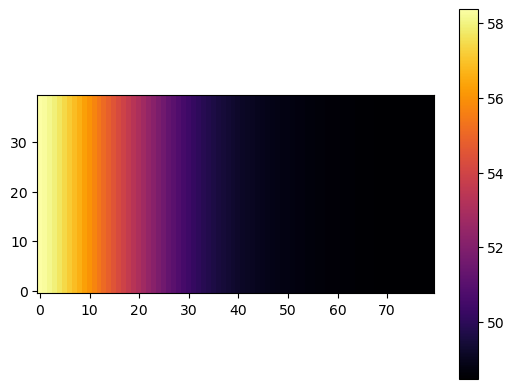

In [5]:
import h5py
import matplotlib.pyplot as plt

with h5py.File(file, "r") as hf:
    T = hf["case/T"][0]   # ONLY first timestep

plt.imshow(T, origin="lower", cmap="inferno")
plt.colorbar()
plt.show()


In [1]:
import h5py
import glob

cases = sorted(glob.glob("pcm_dataset_2D/pcm2D_case_*.h5"))

summary = []
for c in cases:
    with h5py.File(c, "r") as f:
        q = f["case/params"].attrs["heat_flux"]
        summary.append((c, q))

# Print first 10
for s in summary[:10]:
    print(s)


('pcm_dataset_2D\\pcm2D_case_0000.h5', 'callable')
('pcm_dataset_2D\\pcm2D_case_0001.h5', 'callable')
('pcm_dataset_2D\\pcm2D_case_0002.h5', 'callable')
('pcm_dataset_2D\\pcm2D_case_0003.h5', 'callable')
('pcm_dataset_2D\\pcm2D_case_0004.h5', 'callable')
('pcm_dataset_2D\\pcm2D_case_0005.h5', 'callable')
('pcm_dataset_2D\\pcm2D_case_0006.h5', 'callable')
('pcm_dataset_2D\\pcm2D_case_0007.h5', 'callable')
('pcm_dataset_2D\\pcm2D_case_0008.h5', 'callable')
('pcm_dataset_2D\\pcm2D_case_0009.h5', 'callable')


In [2]:
import numpy as np

heat_fluxes = np.linspace(500, 6000, 8)
lengths = np.linspace(0.01, 0.04, 6)
T_inits = [20.0, 30.0, 40.0]

case_map = []
case_id = 0

for q in heat_fluxes:
    for L in lengths:
        for T0 in T_inits:
            case_map.append((case_id, q, L, T0))
            case_id += 1


In [3]:
# Low, medium, high heat flux examples
for cid, q, L, T0 in case_map[::20][:5]:
    print(f"Case {cid:03d} | q = {q:.0f} W/m² | L = {L:.3f} m | T0 = {T0}")


Case 000 | q = 500 W/m² | L = 0.010 m | T0 = 20.0
Case 020 | q = 1286 W/m² | L = 0.010 m | T0 = 40.0
Case 040 | q = 2071 W/m² | L = 0.016 m | T0 = 30.0
Case 060 | q = 2857 W/m² | L = 0.022 m | T0 = 20.0
Case 080 | q = 3643 W/m² | L = 0.022 m | T0 = 40.0


In [3]:
import os
os.getcwd()


'C:\\Users\\raksh'

In [8]:
%cd C:/Users/raksh/Data_driven-PCM-model


C:\Users\raksh\Data_driven-PCM-model


In [9]:
!git status


On branch main

No commits yet

nothing to commit (create/copy files and use "git add" to track)


In [10]:
!dir


 Volume in drive C is Windows
 Volume Serial Number is 7423-F906

 Directory of C:\Users\raksh\Data_driven-PCM-model

19-01-2026  19:15    <DIR>          .
19-01-2026  19:42    <DIR>          ..
               0 File(s)              0 bytes
               2 Dir(s)  48,716,636,160 bytes free


In [11]:
!dir /a


 Volume in drive C is Windows
 Volume Serial Number is 7423-F906

 Directory of C:\Users\raksh\Data_driven-PCM-model

19-01-2026  19:15    <DIR>          .
19-01-2026  19:44    <DIR>          ..
19-01-2026  19:43    <DIR>          .git
               0 File(s)              0 bytes
               3 Dir(s)  48,713,310,208 bytes free
